In [127]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
import glob
import os

In [128]:
def standardize(image):
    img=cv2.imread(image)
    grey=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    return (cv2.resize(grey,((128,128))))/255.0

def ft_magnitude(image):
    # image=cv2.imread(image)
    fourier=cv2.dft(np.float32(image),flags=cv2.DFT_COMPLEX_OUTPUT)
    fourier_shift=np.fft.fftshift(fourier)
    magnitude=20*np.log(cv2.magnitude(fourier_shift[:,:,0],fourier_shift[:,:,1]))
    return cv2.normalize(magnitude,None,0,255,cv2.NORM_MINMAX,cv2.CV_8UC1)

def get_freq_bands(image,r1=20,r2=50):
    fourier=np.fft.fft2(image)
    fshift=np.fft.fftshift(fourier)
    mag=np.abs(fshift)
    rows,columns=image.shape
    center_row,center_col=rows//2,columns//2
    y,x=np.ogrid[:rows,:columns]  #calculating distance grid for circular mask
    dist=np.sqrt((x-center_col)**2+(y-center_row)**2)
    low_mask=dist<r1
    mid_mask=(dist>=r1) & (dist<r2)
    high_mask=dist>=r2
    return low_mask*mag, mid_mask*mag, high_mask*mag

def extract_features(band_mag):
    flat = band_mag[band_mag > 0]  # only non-zero (inside mask)
    if len(flat)==0:
        return [0.0] * 7
    log_mag = np.log(flat + 1e-8)
    mean=np.mean(log_mag)
    std=np.std(log_mag)
    total_energy=np.sum(flat**2)
    log_energy=np.log(total_energy+1e-8)
    variance=np.var(log_mag)
    skewness=float(pd.Series(log_mag).skew())
    norm_mag=flat/(flat.sum()+1e-8)
    entropy=-np.sum(norm_mag * np.log(norm_mag + 1e-12))
    return [mean,std,log_energy,variance,skewness,entropy,
            np.percentile(log_mag,95)-np.percentile(log_mag,5)]

def get_features(image):
    low,mid,high=get_freq_bands(image)
    features=[]
    for band in [low,mid,high]:
        features.extend(extract_features(band))
    low_e=np.sum(low**2)+1e-8
    mid_e=np.sum(mid**2)+1e-8
    high_e=np.sum(high**2)+1e-8
    total=low_e+mid_e+high_e

    features.append(low_e/total)   # low frequency dominance
    features.append(high_e/total)   # high frequency dominance
    features.append(high_e/low_e)
    
    return np.array(features)


In [129]:
image_mags=[]
real_images=[]
fake_images=[]
path="D:/umyma/ml-dl-cv-fundamentals/frequency-domain-analysis/images"
real_path=path+"/real"
fake_path=path+"/fake"
for file in os.listdir(real_path):
    image=os.path.join(real_path,file)
    standardized_image=standardize(image)
    # print(fourier_magnitude)
    # img=cv2.imread(image,cv2.IMREAD_COLOR)
    # cv2.imshow("Image1",fourier_magnitude)
    # cv2.waitKey(0)
    # break
    real_images.append(standardized_image)
    

In [130]:
for file in os.listdir(fake_path):
    image=os.path.join(fake_path,file)
    standardized_image=standardize(image)
    fake_images.append(standardized_image)

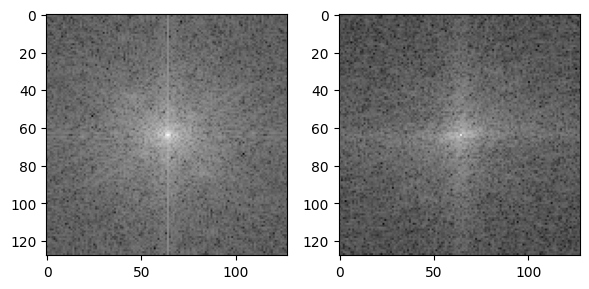

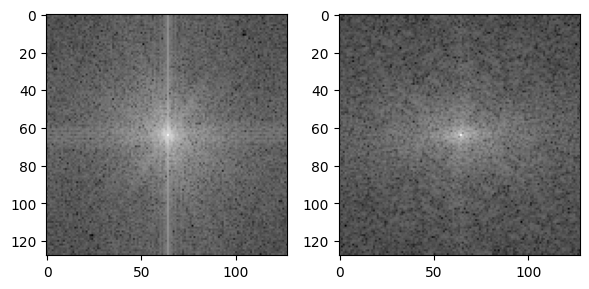

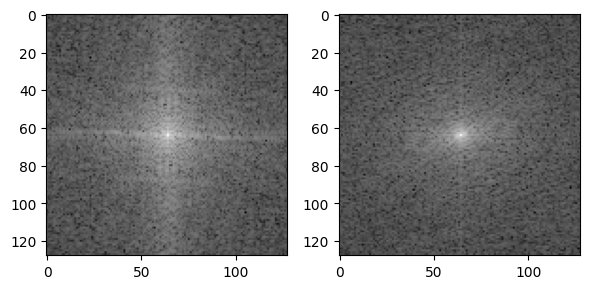

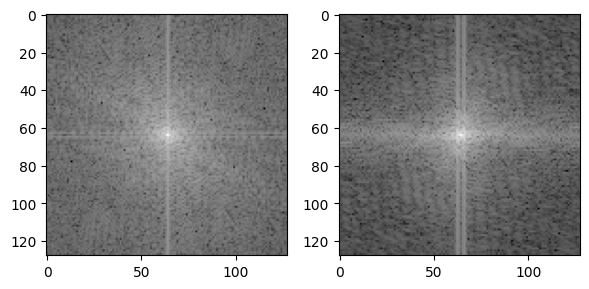

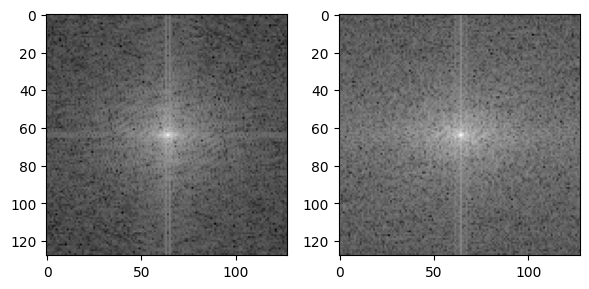

In [131]:
for i in range(5):
    img1,img2=ft_magnitude(real_images[i+1]),ft_magnitude(fake_images[i+1])
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(6,4))
    ax1.imshow(img1,cmap='gray')
    ax2.imshow(img2,cmap='gray')
    plt.tight_layout()
    plt.show()
    j+=1

In [132]:
#building ds
X=[]
y=[]
for image in real_images:
    X.append(get_features(image))
    y.append(0)
for image in fake_images:
    X.append(get_features(image))
    y.append(1)
X=np.array(X)
y=np.array(y)

# [mean,std,log_energy,variance,skewness,entropy,
#             np.percentile(log_mag,95)-np.percentile(log_mag,5)]

# [mean,total_energy,variance,entropy
# #converting to pandas df
columns = [
    "low_mean", "low_std", "low_log_energy", "low_variance", "low_skewness", "low_entropy", "low_dynamic_range",
    "mid_mean", "mid_std", "mid_log_energy", "mid_variance", "mid_skewness", "mid_entropy", "mid_dynamic_range",
    "high_mean", "high_std", "high_log_energy", "high_variance", "high_skewness", "high_entropy", "high_dynamic_range",
    "low_freq_dominance", "high_freq_dominance", "hf_lf_ratio"
]
df=pd.DataFrame(X,columns=columns)
df["label"]=y

In [133]:
df.head()

,low_mean,low_std,low_log_energy,low_variance,low_skewness,low_entropy,low_dynamic_range,mid_mean,mid_std,mid_log_energy,...,high_std,high_log_energy,high_variance,high_skewness,high_entropy,high_dynamic_range,low_freq_dominance,high_freq_dominance,hf_lf_ratio,label
0,3.679313,0.950838,18.502785,0.904093,0.222529,6.223133,3.186306,2.066488,0.789276,13.943649,...,0.716604,12.225697,0.513521,-0.659340,8.840475,2.276597,0.987801,0.001856,0.001879,0
1,3.273215,0.976303,17.292016,0.953168,0.199782,6.248722,3.137627,1.707008,0.766057,13.146065,...,0.678144,11.615706,0.459879,-0.884791,8.882971,2.165219,0.981109,0.003361,0.003426,0
2,3.364804,1.064178,17.844781,1.132474,0.316525,6.142002,3.356393,1.520557,0.817347,13.097203,...,0.718191,11.466833,0.515798,-0.518950,8.807344,2.251707,0.989735,0.001681,0.001699,0
3,3.193751,0.993447,17.429269,0.986936,0.232935,6.223474,3.083636,1.476748,0.814488,12.889127,...,0.722803,11.252419,0.522445,-0.638292,8.844407,2.366253,0.987412,0.002051,0.002077,0
4,3.576972,0.934868,18.195014,0.873977,0.478185,6.202707,3.142816,2.000893,0.774049,13.794189,...,0.702254,12.280423,0.493160,-0.971824,8.865946,2.176655,0.985254,0.002660,0.002700,0


In [134]:
df.groupby("label").mean()

,low_mean,low_std,low_log_energy,low_variance,low_skewness,low_entropy,low_dynamic_range,mid_mean,mid_std,mid_log_energy,...,high_mean,high_std,high_log_energy,high_variance,high_skewness,high_entropy,high_dynamic_range,low_freq_dominance,high_freq_dominance,hf_lf_ratio
label,,,,,,,,,,,,,,,,,,,,,
0,3.317906,0.990517,18.036649,0.984263,0.379521,6.081067,3.233457,1.637227,0.793412,13.159097,...,0.813967,0.715913,11.588120,0.513593,-0.688788,8.836998,2.293394,0.989770,0.001779,0.001802
1,3.381160,0.962469,18.251465,0.930111,0.330756,6.071520,3.119869,1.852473,0.768926,13.503531,...,1.164733,0.699751,12.208985,0.491675,-0.781241,8.855558,2.247107,0.985304,0.003487,0.003588


In [135]:
print(X.shape[1], len(columns))

24 24


In [136]:
df_shuffled=df.sample(frac=1).reset_index(drop=True)


In [137]:
df_shuffled.head()

,low_mean,low_std,low_log_energy,low_variance,low_skewness,low_entropy,low_dynamic_range,mid_mean,mid_std,mid_log_energy,...,high_std,high_log_energy,high_variance,high_skewness,high_entropy,high_dynamic_range,low_freq_dominance,high_freq_dominance,hf_lf_ratio,label
0,3.397637,0.863773,18.771308,0.746104,0.750977,5.909783,2.859900,2.081124,0.751938,13.921523,...,0.719573,12.825996,0.517785,-0.856195,8.854163,2.293639,0.989660,0.002591,0.002618,1
1,3.397258,1.031199,18.161636,1.063371,0.590879,6.029697,3.303143,1.661540,0.832144,13.330459,...,0.771820,11.626054,0.595706,-0.369403,8.765437,2.497364,0.990660,0.001437,0.001451,0
2,3.623132,0.950749,18.352057,0.903924,0.213646,6.221116,3.188616,2.218316,0.763671,14.237125,...,0.713893,12.879208,0.509643,-0.709728,8.852831,2.327184,0.979887,0.004115,0.004199,1
3,3.376464,0.895550,18.267777,0.802010,0.701589,6.078248,2.980516,1.743904,0.765969,13.174855,...,0.667223,11.956402,0.445187,-1.031677,8.894165,2.090614,0.992107,0.001801,0.001816,0
4,3.136641,1.034781,18.786481,1.070772,0.524687,5.693574,3.367562,1.603443,0.758821,12.914092,...,0.661597,11.482855,0.437710,-0.938699,8.896565,2.121979,0.996523,0.000671,0.000673,0


In [138]:
df_shuffled.to_csv("frequency_features.csv")

In [139]:
def spatial_features(image):
    mean=np.mean(image)
    std=np.std(image)
    edges=cv2.Canny((image*255).astype(np.uint8),100,200)
    edge_density=np.sum(edges)/edges.size
    return [mean,std,edge_density]

In [140]:
X_spatial=[]
y=[]
for image in real_images:
    X_spatial.append(spatial_features(image))
    y.append(0)

for image in fake_images:
    X_spatial.append(spatial_features(image))
    y.append(1)

X_spatial=np.array(X_spatial)

In [ ]:
columns=["mean","std","edge_density"]
df_2=pd.DataFrame(X_spatial, columns=columns)
df_2["label"]=y

In [ ]:
df_2_shuffled=df_2.sample(frac=1).reset_index(drop=True)

In [150]:
df_2_shuffled.T

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
mean,0.755170,0.590509,0.379266,0.531472,0.665968,0.576635,0.484255,0.887896,0.473387,0.428895,...,0.746574,0.443126,0.352822,0.530108,0.702947,0.525322,0.794796,0.422891,0.508367,0.698898
std,0.141179,0.246372,0.197841,0.168062,0.260845,0.200129,0.232966,0.188202,0.190325,0.164849,...,0.300903,0.196964,0.220217,0.243380,0.172000,0.281135,0.233758,0.259816,0.199322,0.224672
edge_density,20.108643,37.540283,39.034424,26.645508,33.011169,22.832336,57.866821,21.166992,29.151306,27.423706,...,40.155029,31.501465,33.758240,31.112366,28.295288,26.085205,12.731323,35.283508,39.890442,31.766052
label,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000


In [151]:
df_2_shuffled.to_csv("spatial_features.csv")